### Data Loading Implementation

In [29]:
import os

# Kaggle input directory
KAGGLE_INPUT_DIR = "/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease"

print("Kaggle Input Directory:")
print(KAGGLE_INPUT_DIR)

# Check whether Kaggle input directory exists
if os.path.exists(KAGGLE_INPUT_DIR):
    print("\n✓ Kaggle input directory found.")
else:
    raise FileNotFoundError("Kaggle input directory was not found.")

# List available datasets/folders
items = os.listdir(KAGGLE_INPUT_DIR)

print("\nAvailable items inside /kaggle/input:")
for i, item in enumerate(items, start=1):
    print(f"{i}. {item}")

Kaggle Input Directory:
/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease

✓ Kaggle input directory found.

Available items inside /kaggle/input:
1. validation
2. train


In [30]:
import os

# Verified dataset base path
BASE_DIR = "/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease"

# Exact verified directories
TRAIN_DIR = "/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/train"
VAL_DIR = "/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/validation"

# Verify paths
print("Dataset paths:\n")

print("BASE_DIR:")
print(BASE_DIR)

print("\nTRAIN_DIR:")
print(TRAIN_DIR)

print("\nVAL_DIR:")
print(VAL_DIR)

# Check whether directories exist
print("\nPath verification:")

if os.path.isdir(TRAIN_DIR):
    print("✓ Training directory found.")
else:
    raise FileNotFoundError(f"Training directory not found: {TRAIN_DIR}")

if os.path.isdir(VAL_DIR):
    print("✓ Validation directory found.")
else:
    raise FileNotFoundError(f"Validation directory not found: {VAL_DIR}")

Dataset paths:

BASE_DIR:
/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease

TRAIN_DIR:
/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/train

VAL_DIR:
/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/validation

Path verification:
✓ Training directory found.
✓ Validation directory found.


In [31]:
import os

# Get class folders from the training directory
train_classes = sorted([
    folder for folder in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, folder))
])

# Get class folders from the validation directory
val_classes = sorted([
    folder for folder in os.listdir(VAL_DIR)
    if os.path.isdir(os.path.join(VAL_DIR, folder))
])

# Display class folders
print("Training Classes:")
for i, class_name in enumerate(train_classes, start=1):
    print(f"{i}. {class_name}")

print("\nValidation Classes:")
for i, class_name in enumerate(val_classes, start=1):
    print(f"{i}. {class_name}")

# Check whether train and validation contain the same classes
if train_classes == val_classes:
    print("\n✓ Training and validation contain the same classes.")
else:
    print("\n⚠ Warning: Training and validation class folders are different.")

# Count images for each class
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

train_counts = {}
val_counts = {}

for class_name in train_classes:
    class_path = os.path.join(TRAIN_DIR, class_name)

    train_counts[class_name] = sum(
        1
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)
    )

for class_name in val_classes:
    class_path = os.path.join(VAL_DIR, class_name)

    val_counts[class_name] = sum(
        1
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)
    )

# Display class-wise counts
print("\n" + "=" * 65)
print(f"{'Class':<30} {'Training':>12} {'Validation':>15}")
print("=" * 65)

for class_name in train_classes:
    print(
        f"{class_name:<30} "
        f"{train_counts.get(class_name, 0):>12} "
        f"{val_counts.get(class_name, 0):>15}"
    )

print("=" * 65)

# Total images
total_train_images = sum(train_counts.values())
total_val_images = sum(val_counts.values())
total_images = total_train_images + total_val_images

print(f"\nNumber of classes      : {len(train_classes)}")
print(f"Total training images  : {total_train_images}")
print(f"Total validation images: {total_val_images}")
print(f"Total images           : {total_images}")

# Check class imbalance
print("\nClass imbalance check:")

if train_counts:
    min_train = min(train_counts.values())
    max_train = max(train_counts.values())

    imbalance_ratio = max_train / min_train if min_train > 0 else float("inf")

    print(f"Minimum training images per class: {min_train}")
    print(f"Maximum training images per class: {max_train}")
    print(f"Training imbalance ratio         : {imbalance_ratio:.2f}")

    if imbalance_ratio <= 1.2:
        print("✓ Training dataset is approximately balanced.")
    else:
        print("⚠ Training dataset shows noticeable class imbalance.")

Training Classes:
1. bacterial_leaf_blight
2. brown_spot
3. healthy
4. leaf_blast
5. leaf_scald
6. narrow_brown_spot

Validation Classes:
1. bacterial_leaf_blight
2. brown_spot
3. healthy
4. leaf_blast
5. leaf_scald
6. narrow_brown_spot

✓ Training and validation contain the same classes.

Class                              Training      Validation
bacterial_leaf_blight                   350              88
brown_spot                              350              88
healthy                                 350              88
leaf_blast                              350              88
leaf_scald                              350              88
narrow_brown_spot                       350              88

Number of classes      : 6
Total training images  : 2100
Total validation images: 528
Total images           : 2628

Class imbalance check:
Minimum training images per class: 350
Maximum training images per class: 350
Training imbalance ratio         : 1.00
✓ Training dataset is approxim

## Loading the Rice Leaf Disease Dataset

The Rice Leaf Disease dataset is organized into class-specific folders under the `train` and `validation` directories.

In this step, TensorFlow's `image_dataset_from_directory()` utility is used to create efficient `tf.data.Dataset` objects.

The training dataset will be shuffled because the order of training samples should not remain fixed, while the validation dataset will not be shuffled so that prediction order can be reproduced during evaluation.

In [32]:
import tensorflow as tf

# Reproducibility seed
SEED = 42

# Image configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

# Load validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Store class names
class_names = train_ds.class_names

print("\nClass Names:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print(f"\nNumber of Classes: {len(class_names)}")

Found 2100 files belonging to 6 classes.
Found 528 files belonging to 6 classes.

Class Names:
0: bacterial_leaf_blight
1: brown_spot
2: healthy
3: leaf_blast
4: leaf_scald
5: narrow_brown_spot

Number of Classes: 6


## EfficientNetV2-S Input Preprocessing

EfficientNetV2-S has a model-specific input preprocessing mechanism in the TensorFlow/Keras implementation.

In this project, we will follow the preprocessing expected by the EfficientNetV2-S model instead of applying an additional external normalization step. This avoids unnecessary or duplicated pixel scaling.

The images have already been resized to 224 × 224 pixels during dataset loading. The preprocessing strategy will be kept consistent for training, validation, and later single-image inference.

In [33]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Take one batch from the training dataset
sample_images, sample_labels = next(iter(train_ds))

print("Batch shape :", sample_images.shape)
print("Label shape :", sample_labels.shape)

print("\nPixel value range before model preprocessing:")
print("Minimum pixel value:", tf.reduce_min(sample_images).numpy())
print("Maximum pixel value:", tf.reduce_max(sample_images).numpy())

print("\nData type:", sample_images.dtype)

Batch shape : (16, 224, 224, 3)
Label shape : (16,)

Pixel value range before model preprocessing:
Minimum pixel value: 0.0
Maximum pixel value: 255.0

Data type: <dtype: 'float32'>


## Aggressive Data Augmentation Visualization

In this section, an aggressive but controlled augmentation pipeline is applied to representative training images.

The objective is to increase visual diversity and improve model generalization while preserving important rice leaf disease characteristics.

The augmentation includes:

- Horizontal flipping
- Small rotation
- Zoom
- Translation
- Contrast variation
- Brightness variation

The augmented images are visualized alongside their original images before the final training pipeline is created.

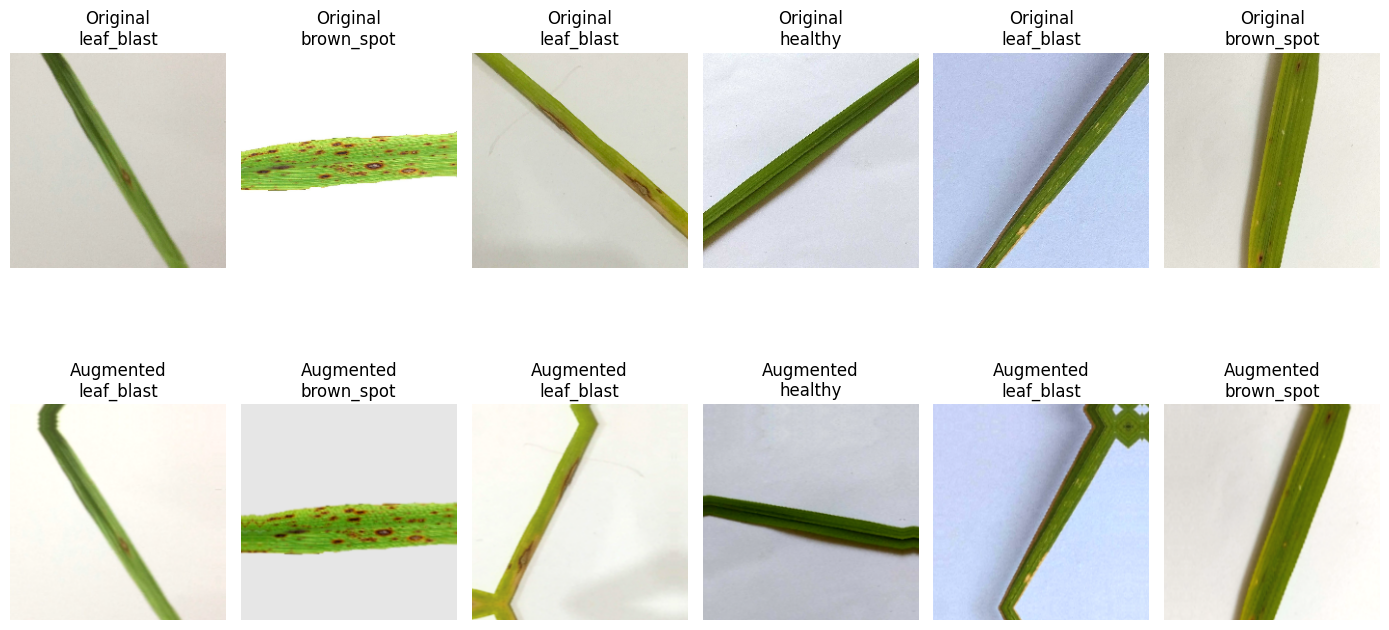

In [34]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers

# ============================================================
# Aggressive but controlled augmentation
# ============================================================

aggressive_augmentation = tf.keras.Sequential([
    layers.RandomFlip(
        mode="horizontal"
    ),

    layers.RandomRotation(
        factor=0.10
    ),

    layers.RandomZoom(
        height_factor=(-0.15, 0.20),
        width_factor=(-0.15, 0.20)
    ),

    layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),

    layers.RandomContrast(
        factor=0.20
    ),

    layers.RandomBrightness(
        factor=0.15
    )
], name="aggressive_augmentation")


# ============================================================
# Get one batch of original training images
# ============================================================

sample_images, sample_labels = next(iter(train_ds))

# Select first 6 images
num_images = 6
images_to_display = sample_images[:num_images]
labels_to_display = sample_labels[:num_images]


# ============================================================
# Generate augmented images
# ============================================================

augmented_images = aggressive_augmentation(
    images_to_display,
    training=True
)


# ============================================================
# Display original and augmented images
# ============================================================

plt.figure(figsize=(14, 8))

for i in range(num_images):

    # Original image
    plt.subplot(2, num_images, i + 1)

    original_image = tf.cast(
        images_to_display[i],
        tf.uint8
    ).numpy()

    plt.imshow(original_image)
    plt.title(f"Original\n{class_names[labels_to_display[i]]}")
    plt.axis("off")

    # Augmented image
    plt.subplot(2, num_images, num_images + i + 1)

    augmented_image = tf.cast(
        tf.clip_by_value(
            augmented_images[i],
            0,
            255
        ),
        tf.uint8
    ).numpy()

    plt.imshow(augmented_image)
    plt.title(f"Augmented\n{class_names[labels_to_display[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Integrating Aggressive Augmentation into the Model

The validated aggressive augmentation pipeline is integrated directly into the EfficientNetV2-S model.

The augmentation layers will be active during training and inactive during validation and inference. This ensures that the validation images remain unchanged and that the same saved model can be used later for single-image prediction.

The EfficientNetV2-S implementation will retain its built-in input preprocessing, so no additional external `Rescaling(1./255)` layer is introduced.

In [35]:
import tensorflow as tf
from tensorflow.keras import layers

# ============================================================
# Configuration
# ============================================================

INPUT_SHAPE = (224, 224, 3)

# ============================================================
# Input layer
# ============================================================

inputs = tf.keras.Input(
    shape=INPUT_SHAPE,
    name="input_image"
)

# ============================================================
# Aggressive but controlled augmentation
# ============================================================

x = aggressive_augmentation(inputs)

# ============================================================
# Check the augmented tensor shape
# ============================================================

print("Input shape       :", inputs.shape)
print("Augmented shape   :", x.shape)

Input shape       : (None, 224, 224, 3)
Augmented shape   : (None, 224, 224, 3)


## Building the EfficientNetV2-S Transfer Learning Model

EfficientNetV2-S is used as the pretrained feature extractor with ImageNet weights.

The pretrained classification head is removed using `include_top=False`, allowing the network to learn rice-leaf disease-specific representations through a new task-specific classifier.

The selected classification head consists of:

EfficientNetV2-S Backbone
↓
Global Average Pooling
↓
Dropout
↓
6-Class Softmax Output

The backbone is initially frozen so that the pretrained visual features are preserved while the new classification head is trained for the rice leaf disease task.

In [36]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# ============================================================
# Configuration
# ============================================================

NUM_CLASSES = len(class_names)
INPUT_SHAPE = (224, 224, 3)

# ============================================================
# Load pretrained EfficientNetV2-S backbone
# ============================================================

base_model = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=INPUT_SHAPE
)

# Freeze backbone for the initial transfer-learning stage
base_model.trainable = False

# ============================================================
# Build classification head
# ============================================================

inputs = tf.keras.Input(
    shape=INPUT_SHAPE,
    name="input_image"
)

# Data augmentation
x = aggressive_augmentation(inputs)

# Pretrained EfficientNetV2-S feature extractor
x = base_model(
    x,
    training=False
)

# Convert feature maps into a single feature vector
x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

# Regularization
x = layers.Dropout(
    rate=0.30,
    name="classifier_dropout"
)(x)

# Final 6-class prediction
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="predictions"
)(x)

# Complete model
model = Model(
    inputs=inputs,
    outputs=outputs,
    name="EfficientNetV2S_RiceLeaf"
)

print("Model created successfully.")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class names: {class_names}")

Model created successfully.
Number of classes: 6
Class names: ['bacterial_leaf_blight', 'brown_spot', 'healthy', 'leaf_blast', 'leaf_scald', 'narrow_brown_spot']


## EfficientNetV2-S Model Summary and Configuration Check

The EfficientNetV2-S model is configured with a dropout rate of 0.30 in the classification head.

In this section, the complete model architecture and parameter distribution are inspected before compilation and training.

The EfficientNetV2-S backbone is currently frozen because the first training phase will use transfer learning.

In [37]:
# ============================================================
# Model configuration verification
# ============================================================

dropout_layer = model.get_layer("classifier_dropout")

print("Model Name:", model.name)
print("Number of Classes:", NUM_CLASSES)
print("Dropout Rate:", dropout_layer.rate)

print("\nModel Architecture:")
model.summary()

# ============================================================
# Parameter counts
# ============================================================

total_params = model.count_params()

trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in model.trainable_weights
)

non_trainable_params = sum(
    tf.keras.backend.count_params(weight)
    for weight in model.non_trainable_weights
)

print("\n" + "=" * 50)
print("PARAMETER SUMMARY")
print("=" * 50)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Non-trainable params : {non_trainable_params:,}")
print("=" * 50)

Model Name: EfficientNetV2S_RiceLeaf
Number of Classes: 6
Dropout Rate: 0.3

Model Architecture:


Model: "EfficientNetV2S_RiceLeaf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aggressive_augmentation         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,339,046 (77.59 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 20,331,360 (77.56 MB)


PARAMETER SUMMARY
Total parameters     : 20,339,046
Trainable parameters : 7,686
Non-trainable params : 20,331,360


## Compiling the Stage-1 Transfer Learning Model

The EfficientNetV2-S model is now compiled for the initial transfer-learning stage.

The pretrained backbone remains frozen, while only the newly added classification head is trainable.

The Adam optimizer is used with an initial learning rate of 0.001. Since the dataset contains six classes with integer labels, Sparse Categorical Crossentropy is appropriate for the classification loss.

Accuracy is used as the initial training metric, while additional metrics such as precision, recall, and F1-score will be calculated separately during final evaluation.

In [38]:
import tensorflow as tf

# ============================================================
# Stage-1 optimizer
# ============================================================

INITIAL_LR = 1e-3

optimizer = tf.keras.optimizers.Adam(
    learning_rate=INITIAL_LR
)

# ============================================================
# Compile model
# ============================================================

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("Model compiled successfully.")
print(f"Optimizer      : Adam")
print(f"Initial LR     : {INITIAL_LR}")
print(f"Loss function  : Sparse Categorical Crossentropy")
print(f"Metric         : Accuracy")

Model compiled successfully.
Optimizer      : Adam
Initial LR     : 0.001
Loss function  : Sparse Categorical Crossentropy
Metric         : Accuracy


## Stage-1 Training Callbacks

Two callbacks are used during the initial transfer-learning stage:

1. ModelCheckpoint
2. ReduceLROnPlateau

ModelCheckpoint saves the model weights corresponding to the best validation loss observed during training.

ReduceLROnPlateau automatically reduces the learning rate when validation loss stops improving for a specified number of epochs.

EarlyStopping is intentionally not used because the training process is required to continue for the predefined number of epochs.

In [39]:
import tensorflow as tf

# ============================================================
# Stage-1 callback configuration
# ============================================================

CHECKPOINT_PATH = "/kaggle/working/efficientnetv2s_stage1_best.keras"

# Save the best model based on validation loss
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# Reduce learning rate when validation loss stops improving
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Callback list
callbacks = [
    checkpoint,
    reduce_lr
]

print("Callbacks created successfully.")
print(f"Checkpoint path: {CHECKPOINT_PATH}")
print("EarlyStopping: NOT USED")
print("Callbacks:")
for cb in callbacks:
    print(f" - {cb.__class__.__name__}")

Callbacks created successfully.
Checkpoint path: /kaggle/working/efficientnetv2s_stage1_best.keras
EarlyStopping: NOT USED
Callbacks:
 - ModelCheckpoint
 - ReduceLROnPlateau


## Stage-1 Transfer Learning Training

The EfficientNetV2-S backbone is frozen during this stage, and only the newly added classification head is trained.

The model will be trained for a fixed 25 epochs using the Adam optimizer with an initial learning rate of 0.001.

EarlyStopping is intentionally not used. ModelCheckpoint will preserve the best model based on validation loss, while ReduceLROnPlateau will reduce the learning rate when validation loss stops improving.

In [40]:
# ============================================================
# Stage-1 Training Configuration
# ============================================================

INITIAL_EPOCHS = 25

print("Stage-1 Training Configuration")
print("=" * 45)
print(f"Epochs              : {INITIAL_EPOCHS}")
print("Backbone            : Frozen")
print("Trainable part      : Classification head")
print("Optimizer           : Adam")
print("Initial learning rate: 1e-3")
print("EarlyStopping       : Not used")
print("ModelCheckpoint     : Enabled")
print("ReduceLROnPlateau   : Enabled")
print("=" * 45)

# ============================================================
# Stage-1 Training
# ============================================================

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Stage-1 Training Configuration
Epochs              : 25
Backbone            : Frozen
Trainable part      : Classification head
Optimizer           : Adam
Initial learning rate: 1e-3
EarlyStopping       : Not used
ModelCheckpoint     : Enabled
ReduceLROnPlateau   : Enabled
Epoch 1/25


E0000 00:00:1786797188.789809      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetV2S_RiceLeaf_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4714 - loss: 1.3882
Epoch 1: val_loss improved from None to 0.71735, saving model to /kaggle/working/efficientnetv2s_stage1_best.keras

Epoch 1: finished saving model to /kaggle/working/efficientnetv2s_stage1_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 41s 153ms/step - accuracy: 0.6171 - loss: 1.0959 - val_accuracy: 0.7727 - val_loss: 0.7174 - learning_rate: 0.0010
Epoch 2/25
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7768 - loss: 0.6899
Epoch 2: val_loss improved from 0.71735 to 0.54923, saving model to /kaggle/working/efficientnetv2s_stage1_best.keras

Epoch 2: finished saving model to /kaggle/working/efficientnetv2s_stage1_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - accuracy: 0.8010 - loss: 0.6446 - val_accuracy: 0.8239 - val_loss: 0.5492 - learning_rate: 0.0010
Epoch 3/25
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8258 - loss: 0.5499
Epoch 3: val_loss improved from 0.54923 to 0.46962, saving 

## Stage-1 Training Performance Visualization

Before starting fine-tuning, the training history of the EfficientNetV2-S
transfer-learning stage is analyzed.

The training and validation accuracy and loss curves are plotted to
understand the learning behavior of the model and identify possible
overfitting or underfitting.

The best Stage-1 checkpoint will be used for final evaluation before
fine-tuning.

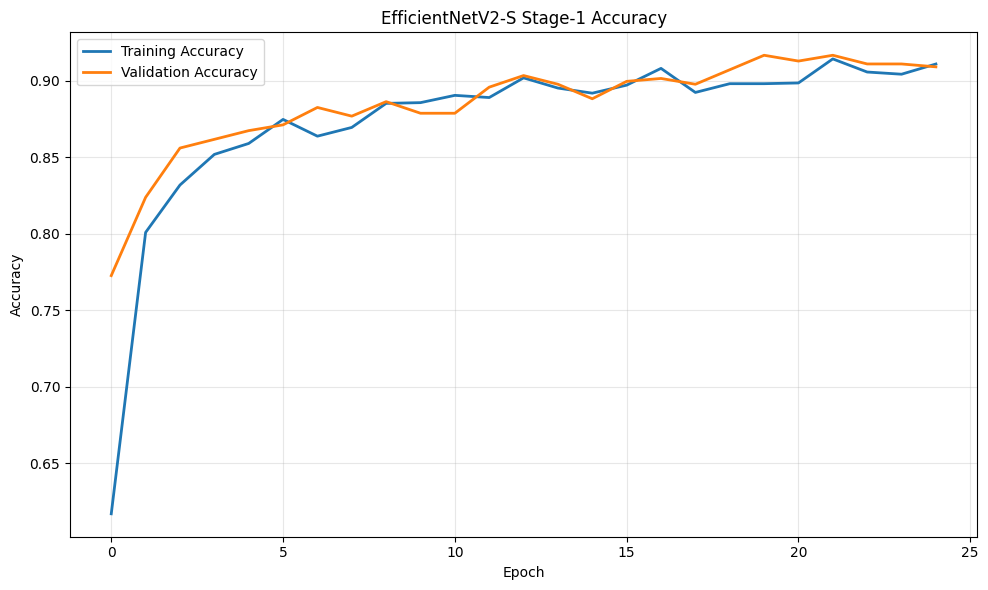

In [41]:
# ============================================================
# Stage-1 Accuracy Curve
# ============================================================

import matplotlib.pyplot as plt

history = history_stage1.history

plt.figure(figsize=(10, 6))

plt.plot(
    history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("EfficientNetV2-S Stage-1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Stage-1 Loss Curve

The training and validation loss curves are plotted to examine how the
classification error changes throughout the 25 training epochs.

A decreasing validation loss indicates improved generalization, whereas
an increasing validation loss while training loss continues to decrease
may indicate overfitting.

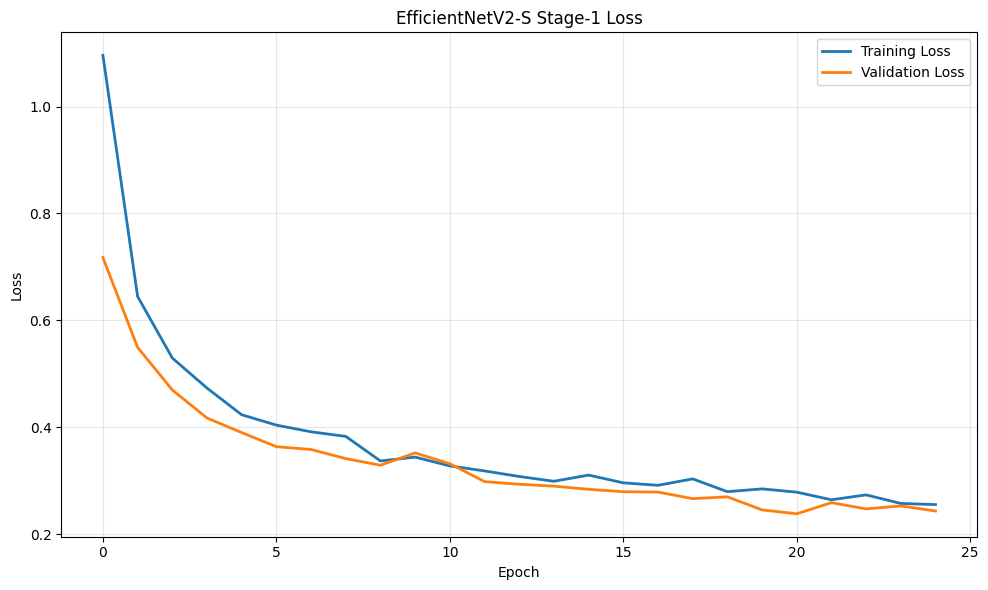

In [42]:
# ============================================================
# Stage-1 Loss Curve
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("EfficientNetV2-S Stage-1 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Loading the Best Stage-1 Checkpoint

The best model saved during Stage-1 training is loaded before performing
the final pre-fine-tuning evaluation.

The checkpoint was selected using validation loss, therefore the model
corresponding to the lowest validation loss is used instead of simply
using the final epoch model.

In [43]:
# ============================================================
# Load Best Stage-1 Model
# ============================================================

BEST_STAGE1_PATH = "/kaggle/working/efficientnetv2s_stage1_best.keras"

best_stage1_model = tf.keras.models.load_model(
    BEST_STAGE1_PATH
)

print("Best Stage-1 model loaded successfully.")
print(f"Checkpoint: {BEST_STAGE1_PATH}")

print("\nModel evaluation:")
best_stage1_model.summary()

Best Stage-1 model loaded successfully.
Checkpoint: /kaggle/working/efficientnetv2s_stage1_best.keras

Model evaluation:


Model: "EfficientNetV2S_RiceLeaf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aggressive_augmentation         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,354,420 (77.65 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

 Optimizer params: 15,374 (60.06 KB)

## Evaluating the Best Stage-1 Model

The best Stage-1 checkpoint is evaluated on the validation dataset.

Validation loss and validation accuracy provide the overall performance
of the model before fine-tuning.

In [44]:
# ============================================================
# Basic Validation Evaluation
# ============================================================

stage1_results = best_stage1_model.evaluate(
    val_ds,
    verbose=1
)

print("\n" + "=" * 50)
print("STAGE-1 VALIDATION RESULTS")
print("=" * 50)

for metric_name, metric_value in zip(
    best_stage1_model.metrics_names,
    stage1_results
):
    print(f"{metric_name:<15}: {metric_value:.4f}")

print("=" * 50)

33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.9129 - loss: 0.2378

STAGE-1 VALIDATION RESULTS
loss           : 0.2378
compile_metrics: 0.9129


## Generating Predictions for Detailed Evaluation

Predictions are generated for every validation image using the best
Stage-1 checkpoint.

The predicted class labels and true class labels will be used to
calculate the confusion matrix, precision, recall, and F1-score.

In [45]:
# ============================================================
# Generate True Labels and Predictions
# ============================================================

import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    
    # Model predictions
    predictions = best_stage1_model.predict(
        images,
        verbose=0
    )
    
    predicted_classes = np.argmax(
        predictions,
        axis=1
    )
    
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Prediction generation completed.")

print(f"Number of validation samples : {len(y_true)}")
print(f"True labels shape             : {y_true.shape}")
print(f"Predicted labels shape        : {y_pred.shape}")

Prediction generation completed.
Number of validation samples : 528
True labels shape             : (528,)
Predicted labels shape        : (528,)


## Confusion Matrix

The confusion matrix shows the number of correctly and incorrectly
classified validation images for each rice leaf disease class.

Rows represent the actual classes, while columns represent the
predicted classes.

The diagonal elements represent correct predictions.

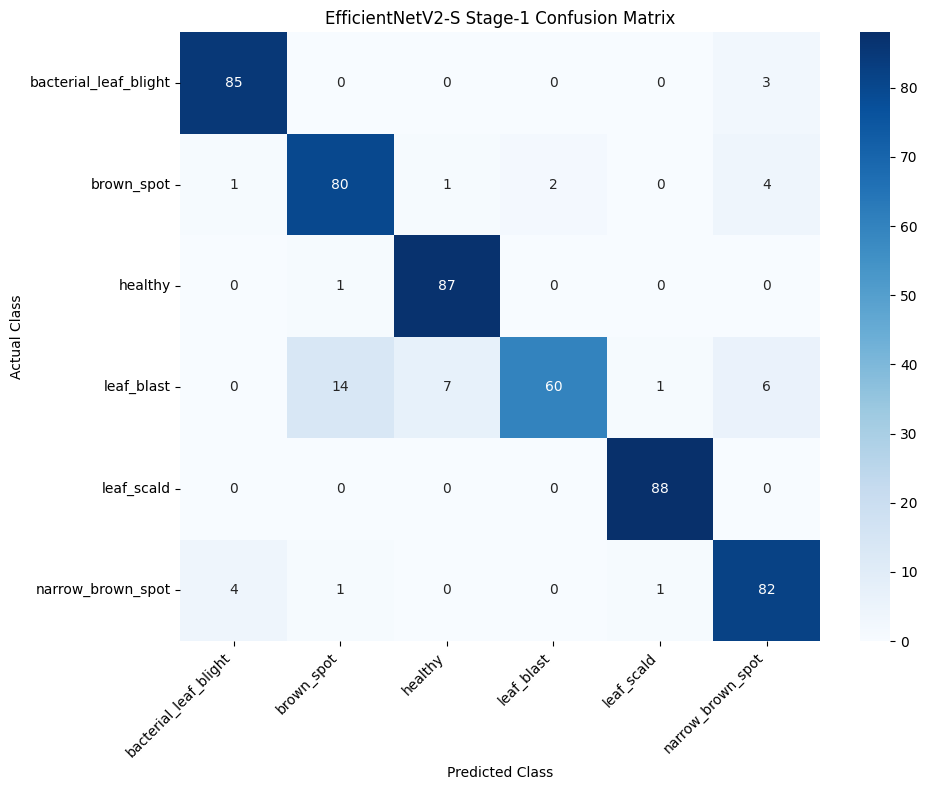

In [46]:
# ============================================================
# Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("EfficientNetV2-S Stage-1 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Classification Metrics

Precision, Recall, F1-score, and overall accuracy are calculated from
the predictions generated by the best Stage-1 checkpoint.

Macro averaging is also reported because it gives equal importance to
all six disease classes.

In [47]:
# ============================================================
# Classification Metrics
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Overall accuracy
accuracy = accuracy_score(
    y_true,
    y_pred
)

# Macro metrics
precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("EFFICIENTNETV2-S STAGE-1 PERFORMANCE")
print("=" * 60)

print(f"Accuracy          : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Macro Precision   : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Macro Recall      : {recall:.4f} ({recall * 100:.2f}%)")
print(f"Macro F1-Score    : {f1:.4f} ({f1 * 100:.2f}%)")

print("=" * 60)

EFFICIENTNETV2-S STAGE-1 PERFORMANCE
Accuracy          : 0.9129 (91.29%)
Macro Precision   : 0.9170 (91.70%)
Macro Recall      : 0.9129 (91.29%)
Macro F1-Score    : 0.9101 (91.01%)


## Stage-2 Fine-Tuning Training

The best Stage-1 EfficientNetV2-S checkpoint is fine-tuned for 25
epochs.

Approximately the final 20% of the backbone layers are trainable,
while the earlier layers remain frozen. Batch Normalization layers
remain frozen to preserve stable pretrained statistics.

The Adam optimizer is used with a reduced learning rate of 1e-5.
The same training dataset and on-the-fly data augmentation pipeline
used during Stage-1 are retained.

EarlyStopping is intentionally not used. ModelCheckpoint saves the
best fine-tuned model based on validation loss, while
ReduceLROnPlateau adaptively reduces the learning rate when validation
loss stops improving.

In [49]:
# ============================================================
# STAGE-2 FINE-TUNING — COMPLETE SETUP IN ONE CELL
# ============================================================

import os
import numpy as np
import tensorflow as tf

print("=" * 70)
print("STAGE-2 FINE-TUNING SETUP")
print("=" * 70)

# ------------------------------------------------------------
# 1. BEST STAGE-1 CHECKPOINT
# ------------------------------------------------------------

BEST_STAGE1_PATH = "/kaggle/working/efficientnetv2s_stage1_best.keras"

if not os.path.exists(BEST_STAGE1_PATH):
    raise FileNotFoundError(
        f"\nBest Stage-1 model NOT found:\n{BEST_STAGE1_PATH}\n\n"
        "Make sure Stage-1 training was completed and the checkpoint "
        "was saved."
    )

print("✓ Stage-1 checkpoint found")
print(BEST_STAGE1_PATH)


# ------------------------------------------------------------
# 2. LOAD BEST STAGE-1 MODEL
# ------------------------------------------------------------

fine_tune_model = tf.keras.models.load_model(
    BEST_STAGE1_PATH
)

print("\n✓ Best Stage-1 model loaded successfully")


# ------------------------------------------------------------
# 3. FIND EfficientNetV2-S BACKBONE
# ------------------------------------------------------------

backbone = None

for layer in fine_tune_model.layers:

    if isinstance(layer, tf.keras.Model):

        if "efficientnetv2" in layer.name.lower():
            backbone = layer
            break

if backbone is None:

    print("\nAvailable model layers:")

    for i, layer in enumerate(fine_tune_model.layers):
        print(
            i,
            layer.name,
            layer.__class__.__name__
        )

    raise ValueError(
        "\nEfficientNetV2-S backbone could not be found."
    )

print("\n✓ Backbone found:")
print(f"  Name   : {backbone.name}")
print(f"  Layers : {len(backbone.layers)}")


# ------------------------------------------------------------
# 4. FIRST FREEZE ENTIRE BACKBONE
# ------------------------------------------------------------

backbone.trainable = True

for layer in backbone.layers:
    layer.trainable = False


# ------------------------------------------------------------
# 5. CALCULATE LAST 20%
# ------------------------------------------------------------

total_backbone_layers = len(backbone.layers)

fine_tune_start = int(
    total_backbone_layers * 0.80
)

print("\nFine-tuning calculation:")
print(f"Total backbone layers : {total_backbone_layers}")
print(f"Frozen first 80%      : 0 - {fine_tune_start - 1}")
print(f"Trainable last 20%    : {fine_tune_start} - {total_backbone_layers - 1}")


# ------------------------------------------------------------
# 6. UNFREEZE LAST 20%
#    BUT KEEP BATCH NORMALIZATION FROZEN
# ------------------------------------------------------------

for layer in backbone.layers[fine_tune_start:]:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False

    else:
        layer.trainable = True


# ------------------------------------------------------------
# 7. CLASSIFICATION HEAD
# ------------------------------------------------------------

# Outer layers other than backbone = classification head
for layer in fine_tune_model.layers:

    if layer is not backbone:

        if isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        ):
            layer.trainable = False

        else:
            layer.trainable = True


# ------------------------------------------------------------
# 8. DOUBLE-CHECK ALL BATCH NORMALIZATION LAYERS
# ------------------------------------------------------------

for layer in backbone.layers:

    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization
    ):
        layer.trainable = False


# ------------------------------------------------------------
# 9. PARAMETER COUNT
# ------------------------------------------------------------

total_params = fine_tune_model.count_params()

trainable_params = np.sum([
    np.prod(variable.shape)
    for variable in fine_tune_model.trainable_variables
])

non_trainable_params = (
    total_params - trainable_params
)


# ------------------------------------------------------------
# 10. DISPLAY PARAMETER SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINE-TUNING PARAMETER SUMMARY")
print("=" * 70)

print(
    f"Total parameters       : {total_params:,}"
)

print(
    f"Trainable parameters   : {trainable_params:,}"
)

print(
    f"Non-trainable params   : {non_trainable_params:,}"
)

print("=" * 70)


# ------------------------------------------------------------
# 11. COMPILE
# ------------------------------------------------------------

FINE_TUNE_EPOCHS = 25
FINE_TUNE_LR = 1e-5

fine_tune_optimizer = tf.keras.optimizers.Adam(
    learning_rate=FINE_TUNE_LR
)

fine_tune_model.compile(
    optimizer=fine_tune_optimizer,

    loss=tf.keras.losses.SparseCategoricalCrossentropy(),

    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("\n✓ Model compiled successfully")

print("\nFinal configuration:")
print(f"  Epochs              : {FINE_TUNE_EPOCHS}")
print(f"  Learning Rate       : {FINE_TUNE_LR}")
print(f"  Backbone            : EfficientNetV2-S")
print(f"  Trainable portion   : Last ~20%")
print(f"  BatchNorm           : Frozen")
print(f"  EarlyStopping       : NOT USED")
print(f"  Optimizer           : Adam")

print("\n" + "=" * 70)
print("READY FOR STAGE-2 FINE-TUNING")
print("=" * 70)

STAGE-2 FINE-TUNING SETUP
✓ Stage-1 checkpoint found
/kaggle/working/efficientnetv2s_stage1_best.keras

✓ Best Stage-1 model loaded successfully

✓ Backbone found:
  Name   : efficientnetv2-s
  Layers : 513

Fine-tuning calculation:
Total backbone layers : 513
Frozen first 80%      : 0 - 409
Trainable last 20%    : 410 - 512

FINE-TUNING PARAMETER SUMMARY
Total parameters       : 20,339,046
Trainable parameters   : 6,917,574
Non-trainable params   : 13,421,472

✓ Model compiled successfully

Final configuration:
  Epochs              : 25
  Learning Rate       : 1e-05
  Backbone            : EfficientNetV2-S
  Trainable portion   : Last ~20%
  BatchNorm           : Frozen
  EarlyStopping       : NOT USED
  Optimizer           : Adam

READY FOR STAGE-2 FINE-TUNING


## Stage-2 Fine-Tuning Training

The configured EfficientNetV2-S model is now fine-tuned for 25 epochs.

The best Stage-1 checkpoint is used as the starting point. The final
20% of backbone layers are trainable, while the first 80% and all
Batch Normalization layers remain frozen.

A learning rate of 1e-5 is used to make small and controlled updates
to the pretrained weights.

The same training dataset with on-the-fly augmentation is used.
Validation images remain unaugmented.

EarlyStopping is intentionally not used. The best fine-tuned model
is saved according to minimum validation loss.

In [50]:
# ============================================================
# STAGE-2 FINE-TUNING TRAINING
# ============================================================

FINE_TUNE_CHECKPOINT = (
    "/kaggle/working/efficientnetv2s_finetuned_best.keras"
)

# ------------------------------------------------------------
# Model Checkpoint
# ------------------------------------------------------------

fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=FINE_TUNE_CHECKPOINT,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# ------------------------------------------------------------
# Reduce Learning Rate
# ------------------------------------------------------------

fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

fine_tune_callbacks = [
    fine_tune_checkpoint,
    fine_tune_reduce_lr
]

print("=" * 70)
print("STAGE-2 TRAINING READY")
print("=" * 70)

print(f"Epochs          : {FINE_TUNE_EPOCHS}")
print(f"Learning Rate   : {FINE_TUNE_LR}")
print(f"Checkpoint      : {FINE_TUNE_CHECKPOINT}")
print("EarlyStopping   : NOT USED")
print("ModelCheckpoint : ENABLED")
print("ReduceLR        : ENABLED")

print("=" * 70)

STAGE-2 TRAINING READY
Epochs          : 25
Learning Rate   : 1e-05
Checkpoint      : /kaggle/working/efficientnetv2s_finetuned_best.keras
EarlyStopping   : NOT USED
ModelCheckpoint : ENABLED
ReduceLR        : ENABLED


In [51]:
# ============================================================
# Stage-2 Fine-Tuning Configuration
# ============================================================

FINE_TUNE_EPOCHS = 25
FINE_TUNE_LR = 1e-5

FINE_TUNE_CHECKPOINT = (
    "/kaggle/working/efficientnetv2s_finetuned_best.keras"
)

# ------------------------------------------------------------
# Compile with a very small learning rate
# ------------------------------------------------------------

fine_tune_optimizer = tf.keras.optimizers.Adam(
    learning_rate=FINE_TUNE_LR
)

fine_tune_model.compile(
    optimizer=fine_tune_optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print("=" * 60)
print("STAGE-2 FINE-TUNING CONFIGURATION")
print("=" * 60)
print(f"Epochs          : {FINE_TUNE_EPOCHS}")
print(f"Learning Rate   : {FINE_TUNE_LR}")
print("Optimizer       : Adam")
print("Trainable       : Last ~20% of backbone")
print("BatchNorm       : Frozen")
print("EarlyStopping   : Not used")
print("=" * 60)

STAGE-2 FINE-TUNING CONFIGURATION
Epochs          : 25
Learning Rate   : 1e-05
Optimizer       : Adam
Trainable       : Last ~20% of backbone
BatchNorm       : Frozen
EarlyStopping   : Not used


## Stage-2 Fine-Tuning Callbacks

A separate checkpoint is used for the fine-tuned model so that the
best Stage-1 model remains preserved.

ModelCheckpoint saves the fine-tuned model with the lowest validation
loss.

ReduceLROnPlateau reduces the learning rate when validation loss stops
improving.

EarlyStopping is not used, so the complete 25-epoch fine-tuning
schedule will be executed.

In [52]:
# ============================================================
# Stage-2 Callbacks
# ============================================================

fine_tune_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=FINE_TUNE_CHECKPOINT,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

fine_tune_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

fine_tune_callbacks = [
    fine_tune_checkpoint,
    fine_tune_reduce_lr
]

print("Stage-2 callbacks created successfully.")
print(f"Best model path: {FINE_TUNE_CHECKPOINT}")
print("EarlyStopping: NOT USED")

Stage-2 callbacks created successfully.
Best model path: /kaggle/working/efficientnetv2s_finetuned_best.keras
EarlyStopping: NOT USED


## Starting Stage-2 Fine-Tuning

The fine-tuned EfficientNetV2-S model is trained for 25 fixed epochs.

The training dataset contains 2,100 original images. Data augmentation
is applied dynamically during training, so augmented images are
generated on-the-fly rather than permanently stored.

The validation dataset contains 528 original images and is used without
random augmentation for objective evaluation.

In [53]:
# ============================================================
# Stage-2 Fine-Tuning
# ============================================================

history_finetune = fine_tune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=fine_tune_callbacks,
    verbose=1
)

print("\nStage-2 Fine-Tuning completed successfully.")

Epoch 1/25


E0000 00:00:1786798525.400788      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetV2S_RiceLeaf_1/efficientnetv2-s_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9114 - loss: 0.2504
Epoch 1: val_loss improved from None to 0.22617, saving model to /kaggle/working/efficientnetv2s_finetuned_best.keras

Epoch 1: finished saving model to /kaggle/working/efficientnetv2s_finetuned_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 49s 174ms/step - accuracy: 0.9138 - loss: 0.2478 - val_accuracy: 0.9129 - val_loss: 0.2262 - learning_rate: 1.0000e-05
Epoch 2/25
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9157 - loss: 0.2284
Epoch 2: val_loss improved from 0.22617 to 0.20644, saving model to /kaggle/working/efficientnetv2s_finetuned_best.keras

Epoch 2: finished saving model to /kaggle/working/efficientnetv2s_finetuned_best.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 18s 139ms/step - accuracy: 0.9229 - loss: 0.2247 - val_accuracy: 0.9299 - val_loss: 0.2064 - learning_rate: 1.0000e-05
Epoch 3/25
131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9237 - loss: 0.2113
Epoch 3: val_loss improved from 0.20

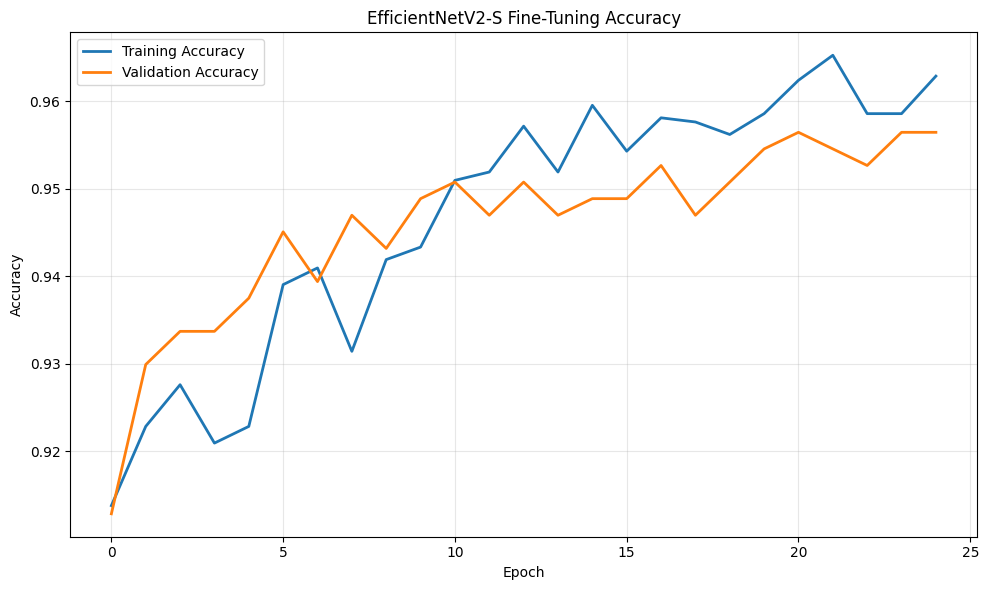

In [54]:
import matplotlib.pyplot as plt

# ============================================================
# Stage-2 Fine-Tuning Accuracy Curve
# ============================================================

history_ft = history_finetune.history

plt.figure(figsize=(10, 6))

plt.plot(
    history_ft["accuracy"],
    label="Training Accuracy",
    linewidth=2
)

plt.plot(
    history_ft["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("EfficientNetV2-S Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

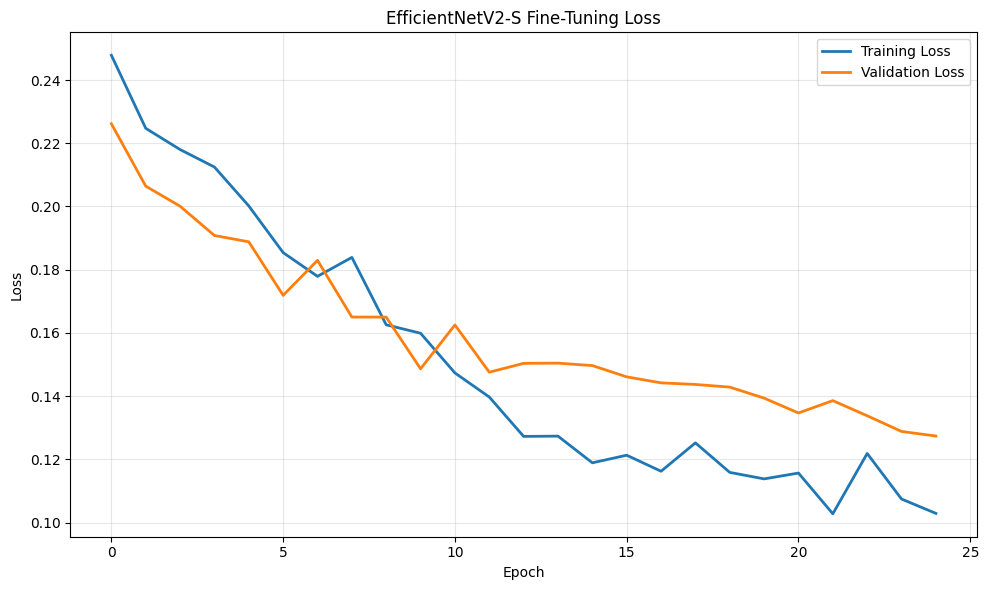

In [55]:
# ============================================================
# Stage-2 Fine-Tuning Loss Curve
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_ft["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history_ft["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("EfficientNetV2-S Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# LOAD BEST FINE-TUNED MODEL
# ============================================================

import os
import tensorflow as tf

BEST_FINETUNED_PATH = (
    "/kaggle/working/efficientnetv2s_finetuned_best.keras"
)

# Verify checkpoint exists
if not os.path.exists(BEST_FINETUNED_PATH):
    raise FileNotFoundError(
        f"Best fine-tuned model not found:\n{BEST_FINETUNED_PATH}"
    )

# Load best checkpoint
best_finetuned_model = tf.keras.models.load_model(
    BEST_FINETUNED_PATH
)

print("=" * 65)
print("BEST FINE-TUNED MODEL LOADED")
print("=" * 65)
print(f"Checkpoint path : {BEST_FINETUNED_PATH}")
print(f"Model name      : {best_finetuned_model.name}")
print("=" * 65)

BEST FINE-TUNED MODEL LOADED
Checkpoint path : /kaggle/working/efficientnetv2s_finetuned_best.keras
Model name      : EfficientNetV2S_RiceLeaf


In [58]:
# ============================================================
# BASIC FINAL EVALUATION
# ============================================================

final_results = best_finetuned_model.evaluate(
    val_ds,
    verbose=1
)

print("\n" + "=" * 65)
print("BEST FINE-TUNED MODEL — FINAL VALIDATION RESULTS")
print("=" * 65)

for metric_name, metric_value in zip(
    best_finetuned_model.metrics_names,
    final_results
):
    print(f"{metric_name:<20}: {metric_value:.4f}")

print("=" * 65)

33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - accuracy: 0.9564 - loss: 0.1274

BEST FINE-TUNED MODEL — FINAL VALIDATION RESULTS
loss                : 0.1274
compile_metrics     : 0.9564


## Final Classification Metrics — Fine-Tuned EfficientNetV2-S

The best fine-tuned EfficientNetV2-S checkpoint is evaluated using
multiple classification metrics.

Overall accuracy is reported together with macro-averaged and
weighted-averaged precision, recall, and F1-score.

A detailed classification report is also generated for each of the
six rice leaf disease classes.

In [61]:
# ============================================================
# FINAL CLASSIFICATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# Overall Accuracy
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)

# ------------------------------------------------------------
# Macro Metrics
# Each class gets equal importance
# ------------------------------------------------------------

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

# ------------------------------------------------------------
# Weighted Metrics
# Classes are weighted according to their support
# ------------------------------------------------------------

weighted_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

# ------------------------------------------------------------
# Display Overall Metrics
# ------------------------------------------------------------

print("=" * 70)
print("FINE-TUNED EFFICIENTNETV2-S — FINAL PERFORMANCE")
print("=" * 70)

print(f"Accuracy             : {accuracy:.4f}  ({accuracy * 100:.2f}%)")

print("\nMacro Average:")
print(f"Precision            : {macro_precision:.4f}  ({macro_precision * 100:.2f}%)")
print(f"Recall               : {macro_recall:.4f}  ({macro_recall * 100:.2f}%)")
print(f"F1-Score             : {macro_f1:.4f}  ({macro_f1 * 100:.2f}%)")

print("\nWeighted Average:")
print(f"Precision            : {weighted_precision:.4f}  ({weighted_precision * 100:.2f}%)")
print(f"Recall               : {weighted_recall:.4f}  ({weighted_recall * 100:.2f}%)")
print(f"F1-Score             : {weighted_f1:.4f}  ({weighted_f1 * 100:.2f}%)")

print("\n" + "=" * 70)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

print("=" * 70)

FINE-TUNED EFFICIENTNETV2-S — FINAL PERFORMANCE
Accuracy             : 0.9564  (95.64%)

Macro Average:
Precision            : 0.9579  (95.79%)
Recall               : 0.9564  (95.64%)
F1-Score             : 0.9559  (95.59%)

Weighted Average:
Precision            : 0.9579  (95.79%)
Recall               : 0.9564  (95.64%)
F1-Score             : 0.9559  (95.59%)

DETAILED CLASSIFICATION REPORT
                       precision    recall  f1-score   support

bacterial_leaf_blight     1.0000    0.9886    0.9943        88
           brown_spot     0.8830    0.9432    0.9121        88
              healthy     0.9667    0.9886    0.9775        88
           leaf_blast     0.9733    0.8295    0.8957        88
           leaf_scald     0.9888    1.0000    0.9944        88
    narrow_brown_spot     0.9355    0.9886    0.9613        88

             accuracy                         0.9564       528
            macro avg     0.9579    0.9564    0.9559       528
         weighted avg     0.9579    

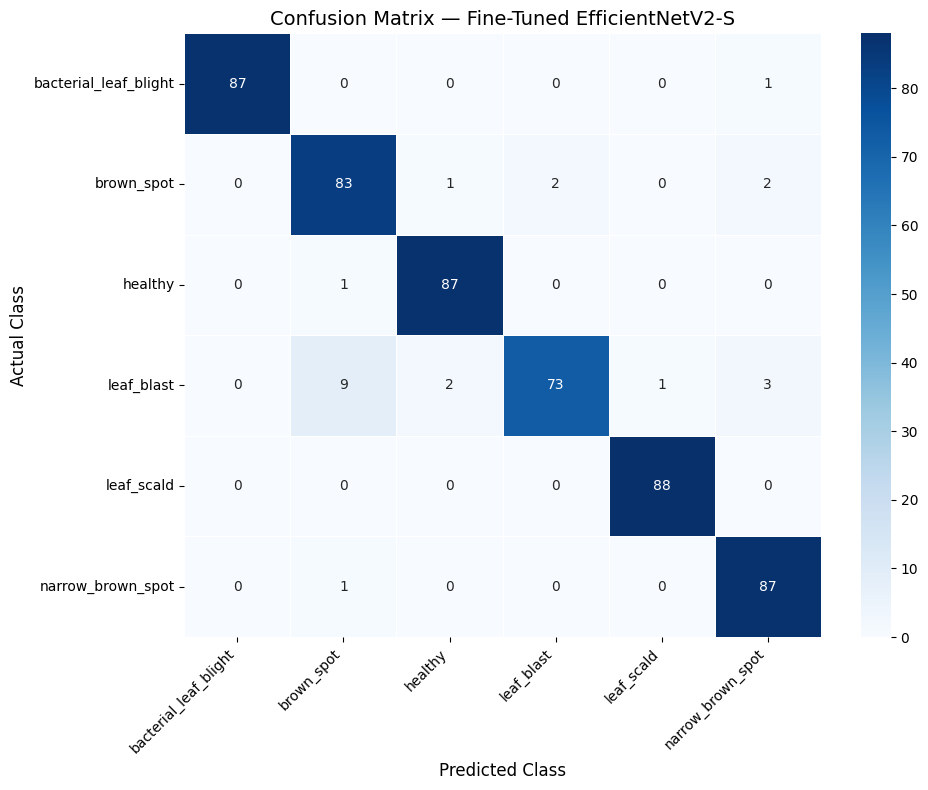

In [62]:
# ============================================================
# CONFUSION MATRIX — FINE-TUNED MODEL
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)

plt.title(
    "Confusion Matrix — Fine-Tuned EfficientNetV2-S",
    fontsize=14
)

plt.xlabel(
    "Predicted Class",
    fontsize=12
)

plt.ylabel(
    "Actual Class",
    fontsize=12
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

In [64]:
# ============================================================
# SINGLE IMAGE PREDICTION
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


def predict_single_image(image_path):
    """
    Predict the disease class of a single rice leaf image.

    Parameters
    ----------
    image_path : str
        Path to the rice leaf image.

    Returns
    -------
    predicted_class : str
        Predicted disease class.
    confidence : float
        Prediction confidence in percentage.
    """

    # --------------------------------------------------------
    # Load image
    # --------------------------------------------------------

    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    # --------------------------------------------------------
    # Convert image to NumPy array
    # --------------------------------------------------------

    image_array = tf.keras.utils.img_to_array(
        image
    )

    # --------------------------------------------------------
    # Add batch dimension
    # --------------------------------------------------------

    image_batch = tf.expand_dims(
        image_array,
        axis=0
    )

    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    probabilities = best_finetuned_model.predict(
        image_batch,
        verbose=0
    )[0]

    # --------------------------------------------------------
    # Highest probability class
    # --------------------------------------------------------

    predicted_index = np.argmax(
        probabilities
    )

    predicted_class = class_names[
        predicted_index
    ]

    confidence = probabilities[
        predicted_index
    ] * 100

    # --------------------------------------------------------
    # Display image
    # --------------------------------------------------------

    plt.figure(figsize=(6, 6))

    plt.imshow(
        image
    )

    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%",
        fontsize=13
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Print result
    # --------------------------------------------------------

    print("=" * 60)
    print("SINGLE IMAGE PREDICTION")
    print("=" * 60)

    print(f"Image Path  : {image_path}")
    print(f"Prediction  : {predicted_class}")
    print(f"Confidence  : {confidence:.2f}%")

    print("=" * 60)

    return predicted_class, confidence

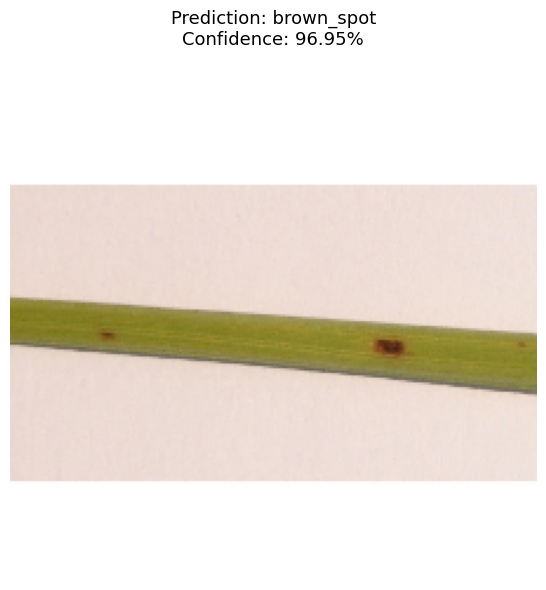

SINGLE IMAGE PREDICTION
Image Path  : /kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/validation/brown_spot/brown_val (18).JPG
Prediction  : brown_spot
Confidence  : 96.95%


In [66]:
# ============================================================
# TEST ONE IMAGE
# ============================================================

image_path = "/kaggle/input/datasets/dedeikhsandwisaputra/rice-leafs-disease-dataset/RiceLeafsDisease/validation/brown_spot/brown_val (18).JPG"

predicted_class, confidence = predict_single_image(
    image_path
)

In [67]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

FINAL_MODEL_PATH = (
    "/kaggle/working/"
    "EfficientNetV2S_RiceLeaf_Final.keras"
)

# Load the best fine-tuned checkpoint explicitly
final_model = tf.keras.models.load_model(
    BEST_FINETUNED_PATH
)

# Save final model with a clean final name
final_model.save(
    FINAL_MODEL_PATH
)

print("=" * 65)
print("FINAL MODEL SAVED SUCCESSFULLY")
print("=" * 65)
print(f"Model path : {FINAL_MODEL_PATH}")

# ------------------------------------------------------------
# Verify saved file
# ------------------------------------------------------------

import os

if os.path.exists(FINAL_MODEL_PATH):

    file_size_mb = (
        os.path.getsize(FINAL_MODEL_PATH)
        / (1024 ** 2)
    )

    print(f"File size  : {file_size_mb:.2f} MB")
    print("✓ Model file verified.")

else:

    raise FileNotFoundError(
        "Final model was not saved correctly."
    )

print("=" * 65)

FINAL MODEL SAVED SUCCESSFULLY
Model path : /kaggle/working/EfficientNetV2S_RiceLeaf_Final.keras
File size  : 132.10 MB
✓ Model file verified.


In [68]:
# ============================================================
# VERIFY LOADED FINAL MODEL
# ============================================================

loaded_final_model = tf.keras.models.load_model(
    FINAL_MODEL_PATH
)

print("✓ Final saved model loaded successfully.")
print("Model name:", loaded_final_model.name)

✓ Final saved model loaded successfully.
Model name: EfficientNetV2S_RiceLeaf
